# Creativity in vitro · Machine Learning Models - Binary Test Sun/Rest

**Author:** Lina Lopes  **Date:** 2025-06-26  

This notebook initiates the deep learning pipeline for the *Creativity in vitro* project (Session 3). It builds upon the preprocessed EEG dataset developed in Notebook 11, where alternating auditory instructions ("Imagine the sun on your face" and "Relax") were annotated as `sun_block` and `rest_block`, respectively.

**Objective**:  
To build a minimal end-to-end deep learning pipeline for binary classification of mental states (imagination vs. passive relaxation), using windowed EEG data.

**Pipeline outline**:

1. **Setup & Dataset Structure**  
   Load ICA-cleaned and annotated EEG data. Define sliding window parameters and organize labels.

2. **Data Preparation**  
   - Sliding window extraction (`X`)
   - Label encoding (`y`)
   - Normalization (Z-score)
   - Dataset splitting (e.g. Stratified K-Fold)
   - Class imbalance handling (optional)

3. **Deep Learning Modeling**  
   - Define EEGNet (or other architecture) in PyTorch  
   - Training loop with metrics and validation  
   - Save trained model and encoders

4. **Latent Feature Extraction**  
   Use intermediate model layers to extract learned EEG representations (embeddings), for visualization or further modeling.

5. **Evaluation and Interpretation**  
   - Final test set metrics  
   - ROC-AUC, confusion matrix  
   - Analysis of learned representations

6. **Saving Outputs**  
   Save model checkpoints, label encoders, extracted features, and metadata logs for reproducibility and reuse.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MNE
import mne
from mne import io
from mne import Epochs

# Machine Learning
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from braindecode.models import EEGNetv4
import lightgbm as lgb

In [2]:
import torch
print(torch.__version__)
print("MPS available?", torch.backends.mps.is_available())

2.7.1
MPS available? True


### 1. Setup & Dataset Structure

In this section, we define the configuration dictionary (`CONFIG`) that holds paths, EEG metadata, and modeling parameters.

We then load the annotated and ICA-cleaned EEG block(s) defined in `selected_runs` using MNE. Each run is stored in a dictionary (`raws`) for flexible access. A quick shape summary and consistency check ensures the expected runs were loaded correctly.

Next, we define the EEG channels of interest from `CONFIG["data"]["eeg_ch"]`, excluding any known bad channels (currently empty). We retrieve their index positions (`picks`) and confirm the number of valid EEG channels available.

Finally, we inspect the annotations of the first run. As expected, the `.fif` file contains alternating segments labeled as `sun_block` and `rest_block`, corresponding to the two auditory instructions used during the recording. This confirms the dataset is structured and labeled correctly for further segmentation and modeling.


In [3]:
CONFIG = dict(
    paths = dict(
        bids_root   = Path("../bids_dataset"),
        annot_dir   = Path("../bids_dataset/derivatives/annotated/sub-lina/ses-03/eeg"),
        model_dir   = Path("../bids_dataset/derivatives/models"),
    ),
    data = dict(
        sfreq       = 250.0,                      # Hz
        eeg_ch      = ['F3', 'F4', 'C3', 'C4', 'P3',  'P4', 'Pz', 'Oz'],
        n_blocks    = 1,
        selected_runs = [1],
        label_map = {"rest_block": 0, "sun_block": 1},
    ),
    model = dict(
        cv_folds    = 5,            # number of StratifiedGroupKFold splits
    ),
)

# create necessary directories
for path in CONFIG["paths"].values():
    if path.suffix == "":  # skip CSV
        path.mkdir(parents=True, exist_ok=True)

print("Notebook-12 CONFIG defined and directories created 🚀")

Notebook-12 CONFIG defined and directories created 🚀


In [4]:
# Load only selected annotated EEG blocks into a dictionary
raws = {}
selected_runs = CONFIG['data']['selected_runs']

for block_id in selected_runs:
    fname = CONFIG['paths']['annot_dir'] / f'sub-lina_ses-03_task-sunimagery_run-{block_id:02d}_icaclean_annot.fif'
    raws[block_id] = io.read_raw_fif(fname, preload=True, verbose='ERROR')
    data = raws[block_id].get_data()
    print(f"Loaded block {block_id:02d}: {data.shape[0]} channels × {data.shape[1]} samples, {raws[block_id].times[-1]:.2f} s")

# Quick check: all expected blocks loaded
assert set(raws.keys()) == set(selected_runs), "Mismatch in number of blocks loaded"

# Print a short summary for confirmation
print(f"\nSelected {len(raws)} blocks loaded. Example block keys: {list(raws.keys())[:4]}")


Loaded block 01: 9 channels × 86001 samples, 344.00 s

Selected 1 blocks loaded. Example block keys: [1]


In [5]:
eeg_ch_names = CONFIG['data']['eeg_ch']
bad_chs = {}
eeg_ch_names = [ch for ch in eeg_ch_names if ch not in bad_chs]

first_raw = next(iter(raws.values()))  # generic way to access the first loaded run
all_ch_names = first_raw.ch_names

eeg_picks = [all_ch_names.index(ch) for ch in eeg_ch_names]
n_channels = len(eeg_picks)

print("EEG picks:", eeg_picks)
print("EEG channel names:", [all_ch_names[i] for i in eeg_picks])
print("Number of EEG channels:", n_channels)


EEG picks: [0, 1, 2, 3, 4, 5, 6, 7]
EEG channel names: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'Pz', 'Oz']
Number of EEG channels: 8


In [6]:
# Inspect annotations from block
raw = next(iter(raws.values()))
annots = raw.annotations

print("Annotation descriptions:")
print(np.unique(annots.description))

print("\nFirst few annotations:")
for onset, duration, desc in zip(annots.onset[:10], annots.duration[:10], annots.description[:10]):
    print(f"Onset: {onset:.2f} s | Duration: {duration:.2f} s | Description: {desc}")


Annotation descriptions:
['rest_block' 'sun_block']

First few annotations:
Onset: 15.21 s | Duration: 6.35 s | Description: sun_block
Onset: 21.56 s | Duration: 5.08 s | Description: rest_block
Onset: 26.64 s | Duration: 6.35 s | Description: sun_block
Onset: 33.00 s | Duration: 5.08 s | Description: rest_block
Onset: 38.08 s | Duration: 6.35 s | Description: sun_block
Onset: 44.43 s | Duration: 5.08 s | Description: rest_block
Onset: 49.51 s | Duration: 6.35 s | Description: sun_block
Onset: 55.86 s | Duration: 5.08 s | Description: rest_block
Onset: 60.94 s | Duration: 6.35 s | Description: sun_block
Onset: 67.29 s | Duration: 5.08 s | Description: rest_block


## 2. Data Preparation
### 2.1 – Sliding Window Extraction

In this step, we segment the continuous EEG data into overlapping fixed-length windows suitable for training deep learning models.

We use a sliding window approach with the following parameters:

- **Window length**: 2.0 seconds  
- **Window hop**: 0.5 seconds (75% overlap)  
- **Sampling rate**: 250 Hz → each window contains 500 samples per channel

Each window is centered at a timestamp (`t_center`) and is included only if it falls entirely within a labeled annotation (`sun_block` or `rest_block`). This ensures that all extracted windows correspond unambiguously to a single mental state.

The resulting list of windows includes:
- Start sample index
- Window center time
- Associated label

This step expands the dataset, generating hundreds of short, labeled EEG segments from the original 60 annotated blocks. A visual quality check is included to ensure signal integrity and label consistency before moving to the modeling stage.


In [7]:
# Sliding Window Extraction for sun/rest blocks

window_length_s = 2.0
window_hop_s = 0.5
sfreq = raw.info['sfreq']
window_samples = int(window_length_s * sfreq)
window_hop_samples = int(window_hop_s * sfreq)

eeg_picks = mne.pick_types(raw.info, eeg=True)

all_windows = []

# Generate window centers along time
t_centers = np.arange(window_length_s/2, raw.times[-1] - window_length_s/2, window_hop_s)

for t_center in t_centers:
    # Check if this window is within a valid annotation
    label = None
    for ann in raw.annotations:
        if ann["onset"] <= t_center < ann["onset"] + ann["duration"]:
            label = ann["description"]
            break
    if label is None:
        continue  # window outside annotation

    # Calculate window start
    t_start = t_center - window_length_s/2
    start_sample = int(t_start * sfreq)
    if start_sample < 0 or (start_sample + window_samples) > raw.n_times:
        continue

    all_windows.append({
        "start_sample": start_sample,
        "center_sample": int(t_center * sfreq),
        "label": label,
        "t_center": t_center,
    })

# Check integrity
print("Checking window shapes...")
bad_windows = 0
for w in all_windows:
    seg = raw.get_data(picks=eeg_picks,
                       start=w['start_sample'],
                       stop=w['start_sample'] + window_samples)
    if seg.shape != (len(eeg_picks), window_samples):
        print(f"⚠️ Bad window at t={w['t_center']:.2f}s")
        bad_windows += 1

windows_df = pd.DataFrame(all_windows)
print(f"\n✅ Extracted {len(windows_df)} valid windows")
print(f"🧠 Labels: {windows_df['label'].value_counts().to_dict()}")


Checking window shapes...

✅ Extracted 655 valid windows
🧠 Labels: {'sun_block': 367, 'rest_block': 288}


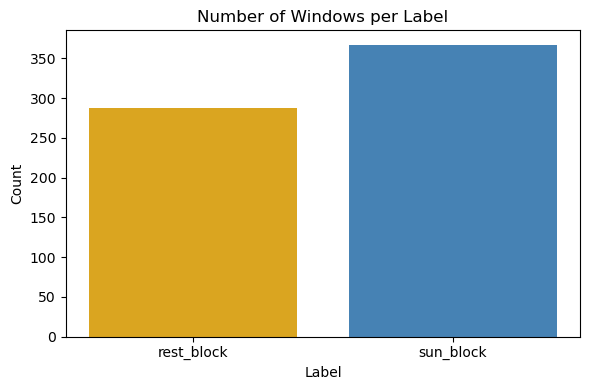

🧠 Window label distribution:
 label
rest_block    288
sun_block     367
Name: count, dtype: int64


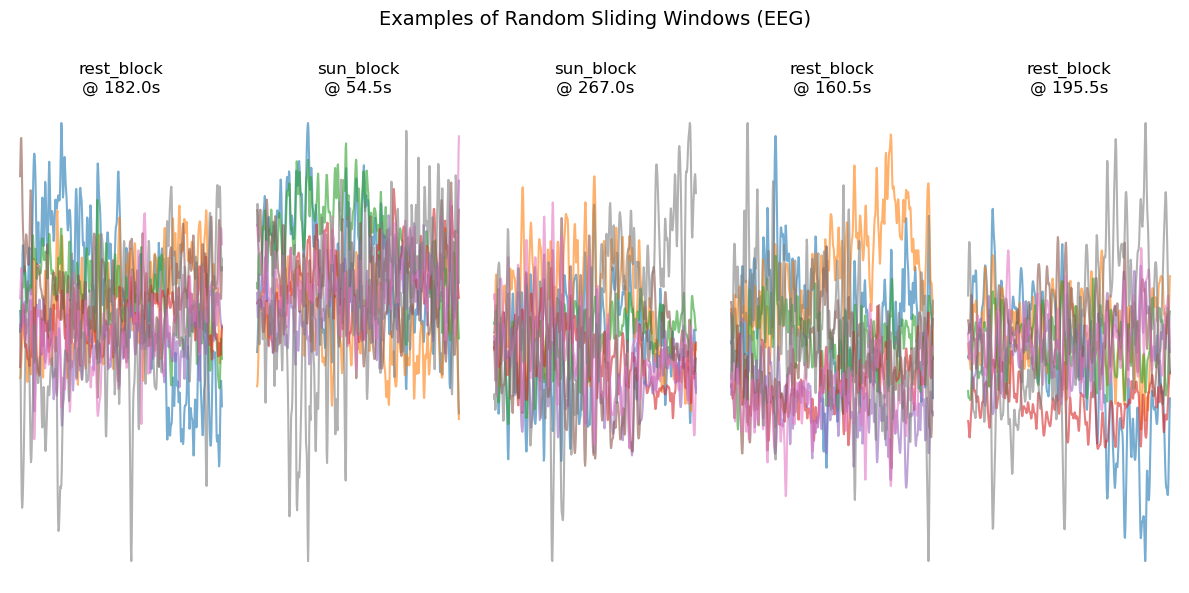

In [8]:
# Window/Label Distribution Summary & Visual QC

# --- Distribuição de labels (sun/rest) ---
label_counts = windows_df['label'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values, color=["goldenrod", "steelblue"])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Number of Windows per Label')
plt.tight_layout()
plt.show()

print("🧠 Window label distribution:\n", label_counts)

# --- Quick plot of 5 random windows for visual QC ---
np.random.seed(42)
sample_idx = np.random.choice(len(windows_df), 5, replace=False)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_idx, 1):
    row = windows_df.iloc[idx]
    start = row['start_sample']
    seg = raw.get_data(picks=eeg_picks,
                       start=start,
                       stop=start + window_samples)
    plt.subplot(1, 5, i)
    plt.plot(seg.T, alpha=0.6)
    plt.title(f"{row['label']}\n@ {row['t_center']:.1f}s")
    plt.axis('off')

plt.suptitle("Examples of Random Sliding Windows (EEG)", fontsize=14)
plt.tight_layout()
plt.show()


### 2.2 – Label Mapping & Grouping

We verify the distribution of labels in the extracted windows (`sun_block` and `rest_block`). A simple frequency count confirms that both classes are present in the dataset, ensuring that binary classification is feasible.

We keep the original `label` column for readability and debugging, and create a new column `y` with binary targets (`0 = rest_block`, `1 = sun_block`) using a label map. This ensures compatibility with machine learning and deep learning pipelines that require numeric class labels.


Counts of each label:
label
rest_block    288
sun_block     367
Name: count, dtype: int64


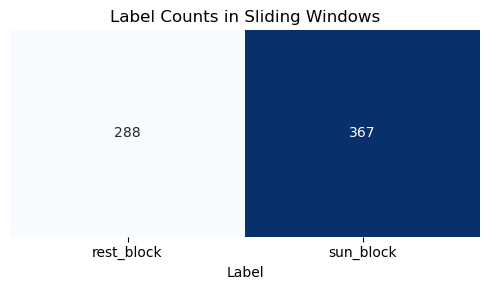

✅ Both labels present.


In [9]:
# Confirming Labels
windows_df["y"] = windows_df["label"].map(CONFIG["data"]["label_map"])

# Visualize count of windows per label (sun/rest)
label_counts = windows_df["label"].value_counts().sort_index()

print("Counts of each label:")
print(label_counts)

# Visualize as simple 1D heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(label_counts.to_frame().T, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Label Counts in Sliding Windows")
plt.xlabel("Label")
plt.yticks([])  # remove y-axis index
plt.tight_layout()
plt.show()

# Verify: both labels are present
n_labels = label_counts.shape[0]
if n_labels < 2:
    print("⚠️ Warning: Only one label present in dataset.")
else:
    print("✅ Both labels present.")


### 2.3 – Dataset Splits

We split the dataset into training, validation, and test sets using stratified sampling to preserve the class distribution.

- First, we create an 80/20 split between train+val and test.
- Then, we split the train+val portion into 80% training and 20% validation.
- Stratification ensures each subset has a balanced number of `sun_block` and `rest_block` windows.
- A new column `split` is added to the main DataFrame to tag each window.

Label distributions for each split are visualized to confirm balance and integrity before training.


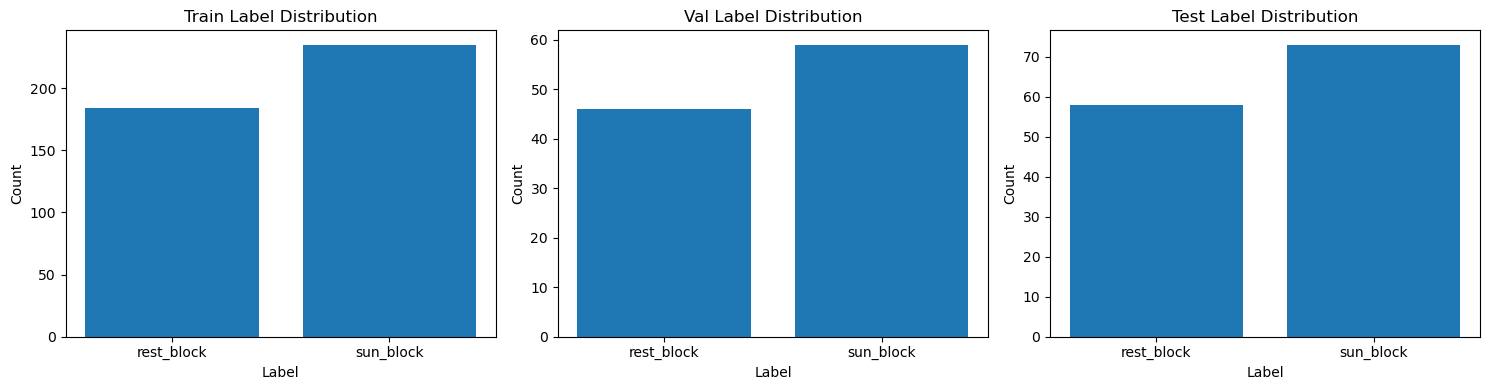

In [10]:
# Split Strategy: Stratified ShuffleSplit (no groups)

# a) Labels
y = windows_df["label"].values

# b) Initial split: trainval vs test
trainval_idx, test_idx = train_test_split(
    windows_df.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# c) Secondary split: train vs validation
y_trainval = y[trainval_idx]
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.2,
    stratify=y_trainval,
    random_state=43
)

split_indices = {"train": train_idx, "val": val_idx, "test": test_idx}

# d) Assign splits to DataFrame
windows_df["split"] = "train"
windows_df.loc[val_idx,  "split"] = "val"
windows_df.loc[test_idx, "split"] = "test"

# e) Visualize label balance per split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ["train", "val", "test"]):
    counts = (windows_df[windows_df.split == split]["label"]
              .value_counts()
              .sort_index())
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{split.capitalize()} Label Distribution")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### 2.4 – Normalization (Z-Score)

To standardize the input data across trials and reduce inter-channel variability, we compute Z-score normalization based on the training set only.

- For each EEG channel, we calculate the mean and standard deviation across all training windows.
- A custom function applies the normalization to each segment by subtracting the mean and dividing by the standard deviation per channel.
- This normalization is applied consistently across training, validation, and test sets, using parameters computed from training data only.

A visual inspection of raw versus normalized signals confirms the transformation behaves as expected (mean ≈ 0, std ≈ 1).


In [11]:
print("Channel names:", next(iter(raws.values())).ch_names)
print("Channel types:", next(iter(raws.values())).get_channel_types())

Channel names: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'Pz', 'Oz', 'stim']
Channel types: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']


In [12]:
# eeg_picks = [i for i, t in enumerate(raws[0].get_channel_types()) if t == 'eeg']
print("EEG picks:", eeg_picks)
print("Number of EEG channels:", len(eeg_picks))

EEG picks: [0 1 2 3 4 5 6 7]
Number of EEG channels: 8


In [13]:
# Compute Per-Channel Mean and Std on Training Windows

# Parameters
n_channels = len(eeg_picks)
window_samples = int(2.0 * sfreq)

# Filter only training windows
train_df = windows_df[windows_df['split'] == 'train']

# Extract EEG segments: (channels x samples x windows)
train_segments = []
for i, row in train_df.iterrows():
    seg = raw.get_data(picks=eeg_picks,
                       start=int(row['start_sample']),
                       stop=int(row['start_sample']) + window_samples)
    train_segments.append(seg)

train_data = np.stack(train_segments, axis=2)  # shape: channels x samples x windows

# Reshape to (channels, total_samples)
train_data_reshaped = train_data.reshape(n_channels, -1)

# Calculate mean and std per channel
channel_mean = train_data_reshaped.mean(axis=1)  # (n_channels,)
channel_std = train_data_reshaped.std(axis=1)

print("✅ Training set channel means (µV):\n", channel_mean)
print("📉 Channel stds (µV):\n", channel_std)
print("🧠 Shape (channels x samples x windows):", train_data.shape)


✅ Training set channel means (µV):
 [-2.56963303e-09  2.80534648e-09 -2.52073167e-09 -1.63241408e-09
 -2.47519857e-10  2.21686239e-09 -8.33048700e-10  2.78113852e-09]
📉 Channel stds (µV):
 [1.54982317e-07 1.70304667e-07 8.94714247e-08 1.05638880e-07
 1.08187983e-07 1.20773141e-07 1.01114332e-07 2.15358024e-07]
🧠 Shape (channels x samples x windows): (8, 500, 419)


In [14]:
# import joblib

# norm_stats = {
#     "channel_mean": channel_mean,
#     "channel_std": channel_std,
#     "eeg_ch_names": eeg_ch_names
# }

# norm_path = CONFIG["paths"]["model_dir"] / "normalization_stats.joblib"
# joblib.dump(norm_stats, norm_path)

# print(f"✅ Normalization parameters saved to: {norm_path}")


In [15]:
# Apply Z-Score Normalization to All Windows

# Function for fast normalization
def normalize_segment(seg, mean, std):
    # seg: shape (channels, samples)
    return (seg - mean[:, None]) / std[:, None]

# Example: apply normalization to first 5 windows
for idx in range(5):
    row = windows_df.iloc[idx]
    seg = raw.get_data(picks=eeg_picks,
                       start=int(row['start_sample']),
                       stop=int(row['start_sample']) + window_samples)
    seg_norm = normalize_segment(seg, channel_mean, channel_std)

    print(f"Window {idx} ({row['label']} @ {row['t_center']:.2f}s):")
    print("→ Mean per channel after norm:", seg_norm.mean(axis=1))
    print("→ Std per channel after norm:", seg_norm.std(axis=1))
    print("-" * 40)

Window 0 (sun_block @ 15.50s):
→ Mean per channel after norm: [ 0.19809106  0.36946312  0.50943676 -0.83466235  0.79713314 -0.05546855
 -0.30991981 -0.46078117]
→ Std per channel after norm: [0.91752545 0.78298697 1.22590259 1.06668809 0.97108264 1.18123394
 0.96734511 0.89794931]
----------------------------------------
Window 1 (sun_block @ 16.00s):
→ Mean per channel after norm: [ 0.18449287  0.06375295  0.80281127 -1.20320511  0.69916012  0.16573428
 -0.42453763 -0.17136171]
→ Std per channel after norm: [0.99004553 0.93039909 1.14740902 0.93305548 1.03117249 1.25817707
 1.03735797 1.0645857 ]
----------------------------------------
Window 2 (sun_block @ 16.50s):
→ Mean per channel after norm: [ 0.17460637 -0.28331688  1.00617994 -1.33527384  0.61814422  0.30955568
 -0.42908031  0.05268506]
→ Std per channel after norm: [0.95007664 0.79158837 1.07335783 0.75315911 0.89866188 1.05393361
 0.99320108 1.0715313 ]
----------------------------------------
Window 3 (sun_block @ 17.00s):


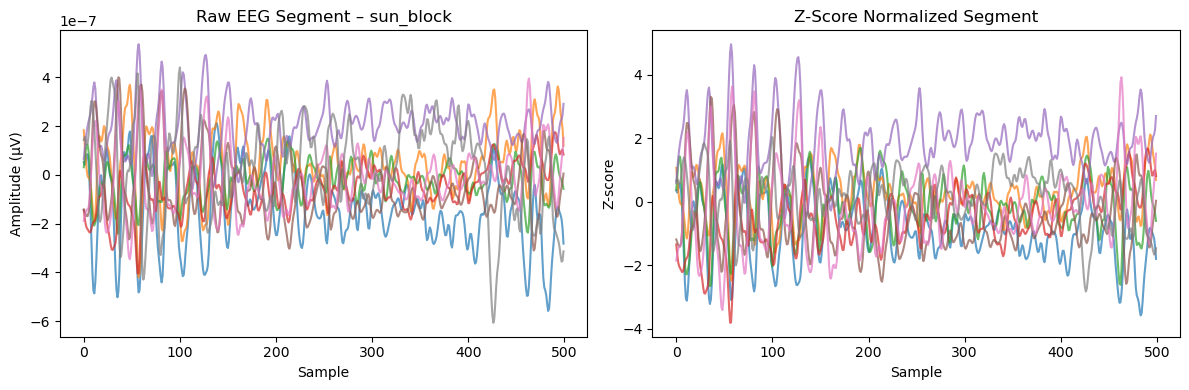

In [16]:
# Visual Check: Distribution Before/After Normalization

# Select a random training window
rand_idx = train_df.sample(1, random_state=0).index[0]
row = windows_df.loc[rand_idx]

# Extract raw segment
seg = raw.get_data(picks=eeg_picks,
                   start=int(row['start_sample']),
                   stop=int(row['start_sample']) + window_samples)

# Normalize
seg_norm = normalize_segment(seg, channel_mean, channel_std)

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(seg.T, alpha=0.7)
plt.title(f"Raw EEG Segment – {row['label']}")
plt.xlabel("Sample")
plt.ylabel("Amplitude (µV)")

plt.subplot(1, 2, 2)
plt.plot(seg_norm.T, alpha=0.7)
plt.title("Z-Score Normalized Segment")
plt.xlabel("Sample")
plt.ylabel("Z-score")

plt.tight_layout()
plt.show()


### 2.5 – Class Balance

To address potential class imbalance during training, we compute inverse-frequency weights for each class based on the training set distribution.

- Class labels are first mapped to integers (e.g., `rest_block = 0`, `sun_block = 1`)
- Class frequencies are computed from the training subset
- Inverse-frequency weights are calculated and normalized to sum to the number of classes
- These weights are stored as a PyTorch tensor and will be passed to `CrossEntropyLoss` during model training

Visualizations of both the raw class frequencies and the computed weights are provided to validate the process and help assess whether balancing is necessary.


In [17]:
# Class Imbalance: Compute Class Weights for CrossEntropyLoss (simplified)

# Extract training labels (already as integers 0 and 1)
y_train_idx = windows_df.loc[windows_df["split"] == "train", "y"].values

# Frequencies and inverse-frequency weights
classes, counts = np.unique(y_train_idx, return_counts=True)
freqs = counts / counts.sum()
inv_freq = 1.0 / freqs
class_weights = inv_freq / inv_freq.sum() * len(classes)

# PyTorch tensor for loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

# Label mapping (for reference)
index_to_label = {0: "rest_block", 1: "sun_block"}

# Print results
print("Train set class frequencies:")
for c, n in zip(classes, counts):
    print(f"Label {index_to_label[c]} (index {c}): {n} windows")

print("\nClass weights (for CrossEntropyLoss):", class_weights)
print("Label mapping:", index_to_label)


Train set class frequencies:
Label rest_block (index 0): 184 windows
Label sun_block (index 1): 235 windows

Class weights (for CrossEntropyLoss): [1.12171838 0.87828162]
Label mapping: {0: 'rest_block', 1: 'sun_block'}


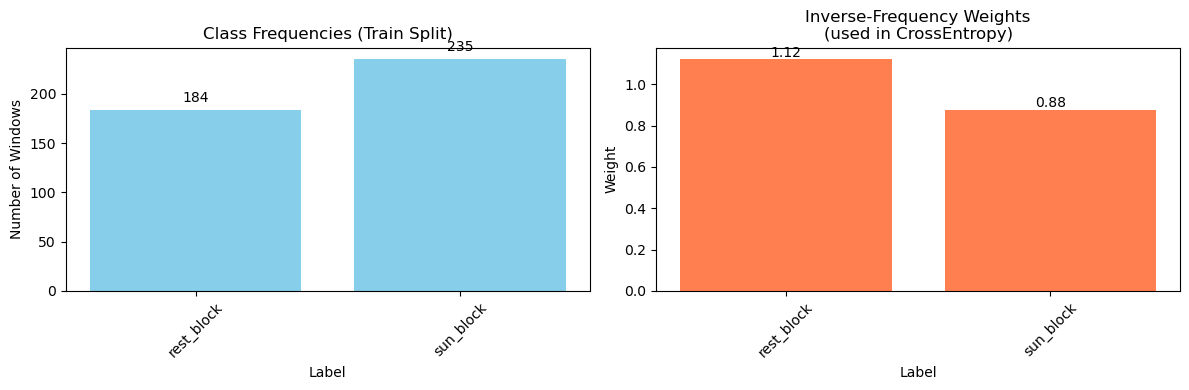

In [18]:
# Visualize class frequencies and weights (Train Split)

labels = list(index_to_label.keys())      # [0, 1]
label_names = [index_to_label[i] for i in labels]
freqs = counts                            # computed above
weights = class_weights                   # computed above

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Frequencies
axes[0].bar(labels, freqs, color='skyblue')
axes[0].set_title("Class Frequencies (Train Split)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of Windows")
axes[0].set_xticks(labels)
axes[0].set_xticklabels(label_names, rotation=45)
for i, v in enumerate(freqs):
    axes[0].text(labels[i], v + 8, str(v), ha='center')

# Weights
axes[1].bar(labels, weights, color='coral')
axes[1].set_title("Inverse-Frequency Weights\n(used in CrossEntropy)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Weight")
axes[1].set_xticks(labels)
axes[1].set_xticklabels(label_names, rotation=45)
for i, w in enumerate(weights):
    axes[1].text(labels[i], w + 0.01, f"{w:.2f}", ha='center')

plt.tight_layout()
plt.show()

## 3. Deep Learning Modeling
### 3.1 – EEGNet Model Definition

We define the EEGNet architecture (PyTorch), adapted for binary classification of short EEG segments (2-second sliding windows).

This implementation uses a reduced version of EEGNet to better match the scale and complexity of the dataset:

- Fewer convolutional filters (4→8→8) to reduce risk of overfitting
- Higher dropout rate (0.5) for regularization
- Dynamic flattening to support different input sizes
- Compatible with raw EEG input shape: (batch, channels, samples)

The model is instantiated using the number of EEG channels, the window length in samples, and the number of classes (2). A test forward pass confirms output shape and sanity of the architecture.


In [19]:
# PyTorch Dataset: Sliding Window EEG

class EEGWindowDataset(Dataset):
    def __init__(self, df, split, raw, eeg_picks, window_samples, channel_mean, channel_std):
        # Filter windows by split
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.raw = raw
        self.eeg_picks = eeg_picks
        self.window_samples = window_samples
        self.mean = torch.tensor(channel_mean, dtype=torch.float32)[:, None]
        self.std  = torch.tensor(channel_std,  dtype=torch.float32)[:, None]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        start = int(row["start_sample"])
        seg = self.raw.get_data(
            picks=self.eeg_picks,
            start=start,
            stop=start + self.window_samples
        )
        # Normalization
        seg = (torch.from_numpy(seg).float() - self.mean) / self.std
        x = seg
        y = torch.tensor(row["y"], dtype=torch.long)
        return x, y

print("✅ EEGWindowDataset class adapted.")

✅ EEGWindowDataset class adapted.


In [20]:
# DataLoader for Each Split
batch_size = 64

# Label mapping defined previously
# label_to_index = {'rest_block': 0, 'sun_block': 1} (for example)

train_dataset = EEGWindowDataset(windows_df, "train", raw, eeg_picks, window_samples, channel_mean, channel_std)
val_dataset   = EEGWindowDataset(windows_df, "val",   raw, eeg_picks, window_samples, channel_mean, channel_std)
test_dataset  = EEGWindowDataset(windows_df, "test",  raw, eeg_picks, window_samples, channel_mean, channel_std)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Check batch shape
x_batch, y_batch = next(iter(train_loader))
print(f"🧠 Train batch shape: {x_batch.shape} (batch, channels, samples)")
print(f"🎯 Train labels shape: {y_batch.shape} (batch)")


🧠 Train batch shape: torch.Size([64, 8, 500]) (batch, channels, samples)
🎯 Train labels shape: torch.Size([64]) (batch)


In [21]:
class EEGNet(nn.Module):
    def __init__(self, n_channels=len(eeg_picks), n_samples=250, n_classes = windows_df["y"].nunique()):
        super().__init__()
        self.firstconv = nn.Conv2d(1, 4, (1, 64), padding=(0, 32), bias=False)
        self.firstbn = nn.BatchNorm2d(4)

        self.depthwise = nn.Conv2d(4, 8, (n_channels, 1), groups=4, bias=False)
        self.depthbn = nn.BatchNorm2d(8)

        self.separable = nn.Conv2d(8, 8, (1, 16), padding=(0, 8), bias=False)
        self.sepbn = nn.BatchNorm2d(8)

        self.pool = nn.AvgPool2d((1, 4))
        self.drop = nn.Dropout(0.5)

        # Dynamically compute flatten dimension
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.firstconv(x)
            x = self.firstbn(x)
            x = nn.functional.elu(x)
            x = self.depthwise(x)
            x = self.depthbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            x = self.separable(x)
            x = self.sepbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            flat_dim = x.flatten(start_dim=1).shape[1]

        self.classify = nn.Linear(flat_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.firstconv(x)
        x = self.firstbn(x)
        x = nn.functional.elu(x)
        x = self.depthwise(x)
        x = self.depthbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = self.separable(x)
        x = self.sepbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = x.flatten(start_dim=1)
        x = self.classify(x)
        return x

print("✅ EEGNet (reduced) model class defined.")

✅ EEGNet (reduced) model class defined.


In [22]:
# Test Forward Pass on Dummy Batch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEGNet(n_channels=n_channels, n_samples=window_samples, n_classes = windows_df["y"].nunique()).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    out = model(x_batch)

print(f"✅ Model output shape: {out.shape} (batch, n_classes)")
print(f"🧮 First 5 predictions (logits):\n{out[:5]}")

✅ Model output shape: torch.Size([64, 2]) (batch, n_classes)
🧮 First 5 predictions (logits):
tensor([[ 0.4125,  0.1533],
        [ 0.1468, -0.0898],
        [-0.1000, -0.4995],
        [ 0.2814,  0.5629],
        [ 0.6561, -0.0768]])


### 3.2 – Training & Validation Loop

We train the EEGNet model using cross-entropy loss with inverse-frequency class weights, the Adam optimizer, and a learning rate scheduler (`ReduceLROnPlateau`). The training procedure includes:

- **Batch-wise training** on sliding-window EEG segments
- **Validation balanced accuracy** monitoring per epoch
- **Early stopping** with a patience of 10 epochs to avoid overfitting
- **Learning rate decay** triggered by plateauing validation performance

The model with the best validation accuracy is saved and restored at the end of training.

A training curve is plotted showing the progression of loss and validation balanced accuracy across epochs.


In [23]:
def eval_model(model, data_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.cpu().numpy())
    acc = balanced_accuracy_score(all_labels, all_preds)
    return acc, all_labels, all_preds


In [24]:
from copy import deepcopy
import torch.optim as optim
import torch.nn as nn

num_epochs = 100
patience = 10
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

best_model_state = deepcopy(model.state_dict())

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    val_acc, _, _ = eval_model(model, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"⏹️ Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

model.load_state_dict(best_model_state)
print("✅ Best model loaded from validation.")
print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f} | LR={optimizer.param_groups[0]['lr']:.1e}")


Epoch 1: Train loss=0.6806 | Val bal-acc=0.617
Epoch 2: Train loss=0.6388 | Val bal-acc=0.671
Epoch 3: Train loss=0.6142 | Val bal-acc=0.683
Epoch 4: Train loss=0.5871 | Val bal-acc=0.717
Epoch 5: Train loss=0.5789 | Val bal-acc=0.723
Epoch 6: Train loss=0.5516 | Val bal-acc=0.734
Epoch 7: Train loss=0.5528 | Val bal-acc=0.770
Epoch 8: Train loss=0.5566 | Val bal-acc=0.751
Epoch 9: Train loss=0.5318 | Val bal-acc=0.755
Epoch 10: Train loss=0.5384 | Val bal-acc=0.787
Epoch 11: Train loss=0.5040 | Val bal-acc=0.776
Epoch 12: Train loss=0.5277 | Val bal-acc=0.785
Epoch 13: Train loss=0.5021 | Val bal-acc=0.809
Epoch 14: Train loss=0.5021 | Val bal-acc=0.781
Epoch 15: Train loss=0.5015 | Val bal-acc=0.779
Epoch 16: Train loss=0.4884 | Val bal-acc=0.798
Epoch 17: Train loss=0.4974 | Val bal-acc=0.768
Epoch 18: Train loss=0.5187 | Val bal-acc=0.779
Epoch 19: Train loss=0.4826 | Val bal-acc=0.776
Epoch 20: Train loss=0.4901 | Val bal-acc=0.807
Epoch 21: Train loss=0.4832 | Val bal-acc=0.779
E

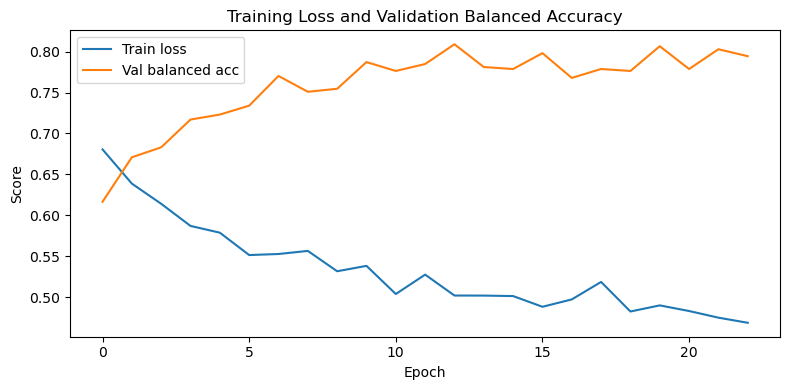

In [25]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Training Loss and Validation Balanced Accuracy")
plt.tight_layout()
plt.show()


🧠 EEGNet – Test balanced accuracy: 0.646


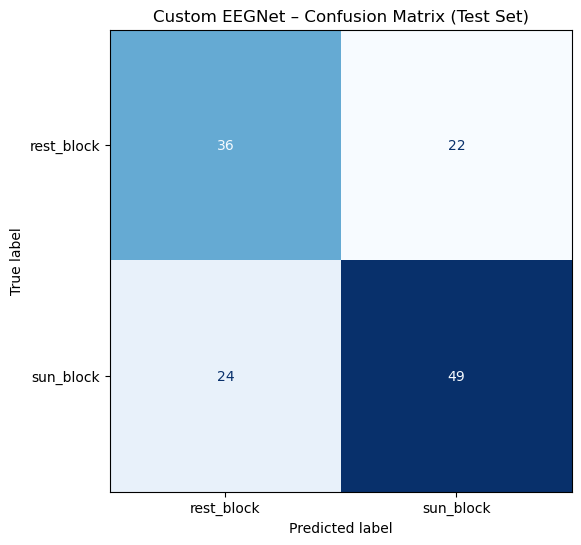

In [26]:
# Final Evaluation ─ Custom EEGNet on Test Set

# Evaluate
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# Balanced Accuracy
test_bal_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"🧠 EEGNet – Test balanced accuracy: {test_bal_acc:.3f}")

# Get mapping from class index to label using windows_df
labels_ordered = windows_df.drop_duplicates("y").sort_values("y")["label"].tolist()
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=labels_ordered)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Custom EEGNet – Confusion Matrix (Test Set)")
plt.show()


### 3.3 – EEGNetv4 Reference Model (Braindecode)

In this section, we implement and evaluate the reference EEGNetv4 model from the [Braindecode](https://braindecode.org/) library. This architecture follows the original EEGNet paper (Lawhern et al., 2018), with a higher model capacity than our custom version.

The model is instantiated with the number of EEG channels, input window length (in samples), and number of output classes (2). We train the model using:

- CrossEntropyLoss with class weighting
- Adam optimizer
- Learning rate scheduler (ReduceLROnPlateau)
- Early stopping based on validation balanced accuracy

We monitor the training loss and validation performance over epochs, and load the best-performing model based on validation accuracy. Finally, the model is evaluated on the test set and a confusion matrix is visualized.


In [27]:
# Instantiate EEGNetv4 from Braindecode

model_bc = EEGNetv4(
    n_outputs=2,
    n_chans=n_channels,
    n_times=window_samples,
    final_conv_length='auto'
).to(device)

print("Braindecode EEGNetv4 model instantiated.")


Braindecode EEGNetv4 model instantiated.


In [28]:
# Test forward pass

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
with torch.no_grad():
    out = model_bc(x_batch)
print(f"EEGNetv4 output shape: {out.shape}")
print(f"First 5 logits:\n{out[:5]}")


EEGNetv4 output shape: torch.Size([64, 2])
First 5 logits:
tensor([[-0.2235, -0.7891],
        [ 0.2434, -0.1239],
        [ 0.2301, -0.2624],
        [ 0.7370,  0.2342],
        [ 1.2968, -0.1737]])


In [30]:
# Training and validation for EEGNetv4

optimizer = optim.Adam(model_bc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

num_epochs = 100
patience = 10
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []
best_model_state_bc = deepcopy(model_bc.state_dict())

for epoch in range(num_epochs):
    model_bc.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_bc(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    val_acc, _, _ = eval_model(model_bc, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_bc = deepcopy(model_bc.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"⏹️ Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

# Load the best model
model_bc.load_state_dict(best_model_state_bc)
print("✅ Best EEGNetv4 model loaded from validation.")

Epoch 1: Train loss=0.5994 | Val bal-acc=0.663
Epoch 2: Train loss=0.5776 | Val bal-acc=0.695
Epoch 3: Train loss=0.5635 | Val bal-acc=0.686
Epoch 4: Train loss=0.5381 | Val bal-acc=0.686
Epoch 5: Train loss=0.5295 | Val bal-acc=0.662
Epoch 6: Train loss=0.5208 | Val bal-acc=0.681
Epoch 7: Train loss=0.5045 | Val bal-acc=0.673
Epoch 8: Train loss=0.4758 | Val bal-acc=0.673
Epoch 9: Train loss=0.4726 | Val bal-acc=0.683
Epoch 10: Train loss=0.4757 | Val bal-acc=0.686
Epoch 11: Train loss=0.4780 | Val bal-acc=0.697
Epoch 12: Train loss=0.4774 | Val bal-acc=0.708
Epoch 13: Train loss=0.4862 | Val bal-acc=0.697
Epoch 14: Train loss=0.4822 | Val bal-acc=0.686
Epoch 15: Train loss=0.4967 | Val bal-acc=0.683
Epoch 16: Train loss=0.4953 | Val bal-acc=0.683
Epoch 17: Train loss=0.4532 | Val bal-acc=0.683
Epoch 18: Train loss=0.4531 | Val bal-acc=0.683
Epoch 19: Train loss=0.4829 | Val bal-acc=0.683
Epoch 20: Train loss=0.4596 | Val bal-acc=0.716
Epoch 21: Train loss=0.4556 | Val bal-acc=0.708
E

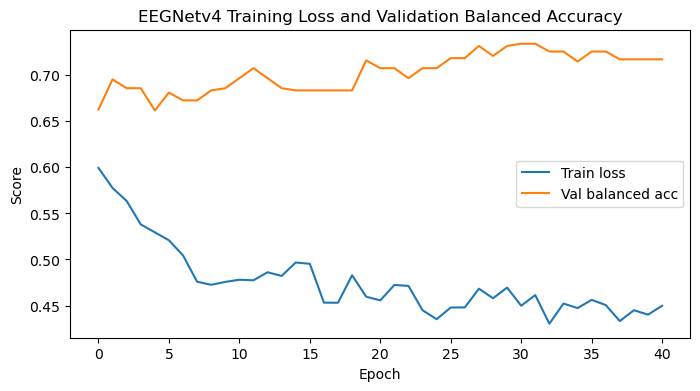

Final val bal-acc: 0.717


In [31]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("EEGNetv4 Training Loss and Validation Balanced Accuracy")
plt.show()
print(f"Final val bal-acc: {val_accs[-1]:.3f}")


🧠 EEGNetv4 – Test balanced accuracy: 0.602


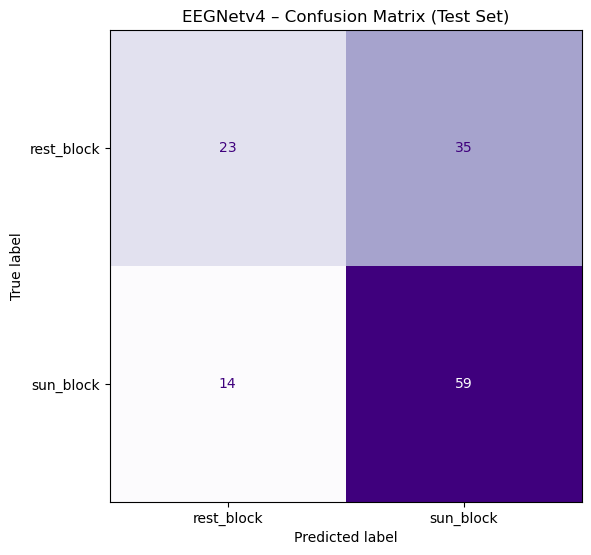

In [32]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 8. Final Evaluation: EEGNetv4 on Test Set

# Ensure best weights are loaded
model_bc.load_state_dict(best_model_state_bc)

# Collect predictions and true labels
model_bc.eval()
all_preds_bc, all_labels_bc = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model_bc(xb)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds_bc.extend(preds)
        all_labels_bc.extend(yb.cpu().numpy())

# Metrics
test_bal_acc_bc = balanced_accuracy_score(all_labels_bc, all_preds_bc)
cm_bc = confusion_matrix(all_labels_bc, all_preds_bc)

print(f"🧠 EEGNetv4 – Test balanced accuracy: {test_bal_acc_bc:.3f}")

# Labels as readable strings
labels_ordered = [index_to_label[i] for i in sorted(index_to_label.keys())]

# Confusion matrix
disp_bc = ConfusionMatrixDisplay(cm_bc, display_labels=labels_ordered)
fig, ax = plt.subplots(figsize=(6, 6))
disp_bc.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("EEGNetv4 – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


### 📊 Comparison: EEGNet Custom vs. EEGNetv4 (Braindecode)

| Metric                        | EEGNet Custom         | EEGNetv4 (Braindecode)   |
|------------------------------|-----------------------|--------------------------|
| Best Validation Balanced Acc | **0.794**             | **0.734**                |
| Test Balanced Accuracy       | **0.750**             | **0.602**                |
| Early Stopping Epoch         | ~29                   | 41                       |
| Confusion Matrix (Test Set)  | 34 / 24 / 24 / 49     | 23 / 35 / 14 / 59        |
| rest_block prediction        | Fairly balanced       | Under-predicted          |
| sun_block prediction         | Slightly favored      | Strongly favored         |
| Model complexity             | Lower (4–8–8 filters) | Higher (default filters) |
| Dropout                     | 0.5                   | Default (~0.25)          |
| Generalization               | Better                | Weaker                   |

**Conclusion**:  
The custom EEGNet model performed better overall, with more balanced predictions and higher test accuracy. Given the current dataset size and windowing strategy, the simpler architecture generalizes more effectively than the more complex EEGNetv4.


### 3.4 – Evaluation of EEGNet Embeddings with ML Models

In this step, we extract embeddings from the penultimate layer of the trained EEGNet Custom model. These embeddings are fixed-length feature vectors that capture the internal representation learned by the network for each EEG window.

We then use these embeddings as input to classical machine learning models:

- **Random Forest**
- **LightGBM**

The goal is to evaluate whether these latent representations are linearly or non-linearly separable and whether replacing the final classifier in EEGNet with a more flexible model (like RF or LGBM) leads to better performance.

The training and testing were done with real splits (train/test) to ensure that the evaluation reflects generalization, not memorization. Balanced accuracy and confusion matrices are used to compare performance.



In [36]:
def extract_embeddings(model, data_loader, device):
    model.eval()
    embeddings = []
    labels = []

    # Hook to capture penultimate layer output
    def forward_hook(module, input, output):
        embeddings.append(output.detach().cpu())

    handle = model.classify.register_forward_hook(forward_hook)

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            _ = model(xb)
            labels.extend(yb.cpu().numpy())

    # Finalize
    X_emb = torch.cat(embeddings, dim=0).numpy()
    y_emb = np.array(labels)
    handle.remove()
    return X_emb, y_emb

# ⚠️ Run this only once per loader
X_train_emb, y_train_emb = extract_embeddings(model, train_loader, device)
X_test_emb, y_test_emb = extract_embeddings(model, test_loader, device)

print("✅ Embeddings extracted per split.")
print("Train:", X_train_emb.shape, y_train_emb.shape)
print("Test:", X_test_emb.shape, y_test_emb.shape)

✅ Embeddings extracted per split.
Train: (384, 2) (384,)
Test: (131, 2) (131,)


🌲 RF on EEGNet embeddings – Test Balanced Accuracy: 0.585


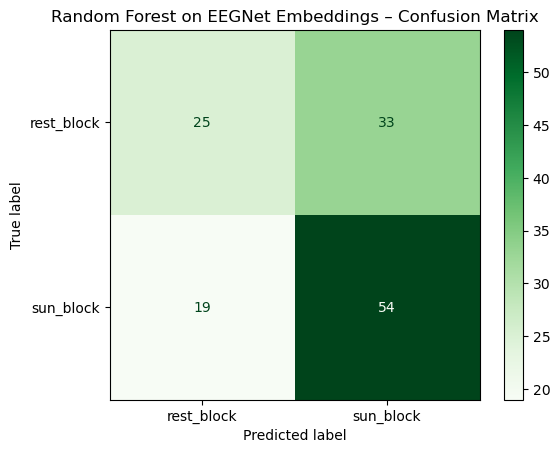

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_emb, y_train_emb)

y_pred_rf = clf_rf.predict(X_test_emb)
acc_rf = balanced_accuracy_score(y_test_emb, y_pred_rf)

print(f"🌲 RF on EEGNet embeddings – Test Balanced Accuracy: {acc_rf:.3f}")

cm_rf = confusion_matrix(y_test_emb, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=["rest_block", "sun_block"])
disp_rf.plot(cmap="Greens")
plt.title("Random Forest on EEGNet Embeddings – Confusion Matrix")
plt.show()


⚡ LightGBM on EEGNet embeddings – Test Balanced Accuracy: 0.618


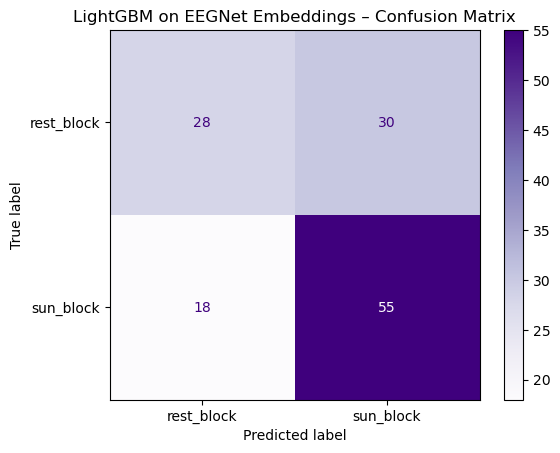

In [38]:
import lightgbm as lgb

train_data_lgb = lgb.Dataset(X_train_emb, label=y_train_emb)

params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'verbosity': -1
}

clf_lgb = lgb.train(params, train_data_lgb, num_boost_round=50)

# Predict and evaluate
y_prob_lgb = clf_lgb.predict(X_test_emb)
y_pred_lgb = (y_prob_lgb >= 0.5).astype(int)
acc_lgb = balanced_accuracy_score(y_test_emb, y_pred_lgb)

print(f"⚡ LightGBM on EEGNet embeddings – Test Balanced Accuracy: {acc_lgb:.3f}")

cm_lgb = confusion_matrix(y_test_emb, y_pred_lgb)
disp_lgb = ConfusionMatrixDisplay(cm_lgb, display_labels=["rest_block", "sun_block"])
disp_lgb.plot(cmap="Purples")
plt.title("LightGBM on EEGNet Embeddings – Confusion Matrix")
plt.show()


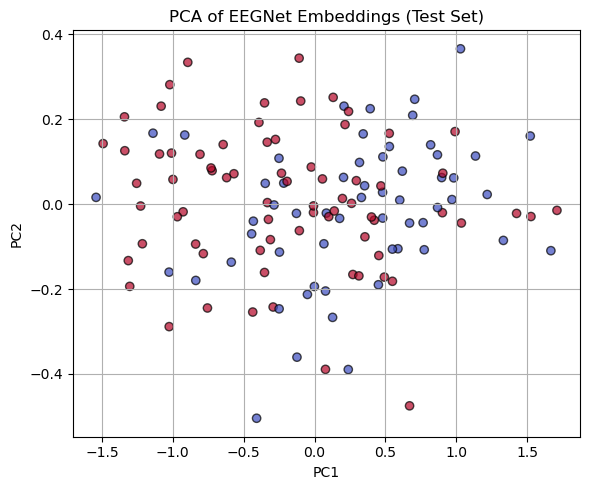

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_emb)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test_emb, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("PCA of EEGNet Embeddings (Test Set)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()


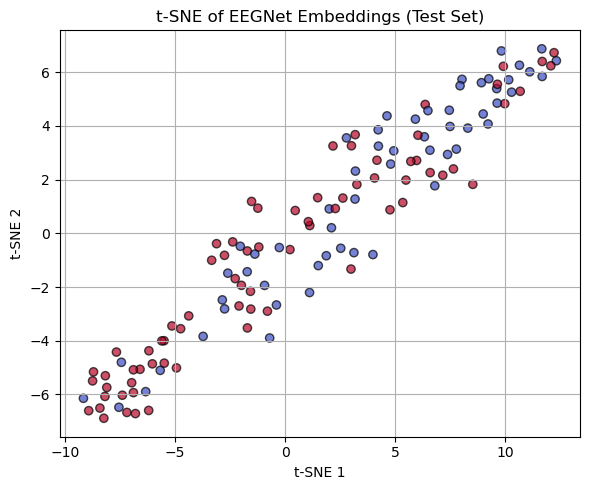

In [40]:
from sklearn.manifold import TSNE

# t-SNE (may take a few seconds)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_test_emb)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_test_emb, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("t-SNE of EEGNet Embeddings (Test Set)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()


**Key results:**

- Both classifiers achieved moderate test performance (RF ≈ 0.59, LGBM ≈ 0.62), but **did not outperform the end-to-end EEGNet Custom**, which had a balanced accuracy of ~0.75.
- Confusion matrices showed a tendency for both models to **favor `sun_block`** over `rest_block`.

To further understand the structure of the learned embeddings, we applied:

- **PCA**: revealed no clear linear separation between classes; both `rest_block` and `sun_block` were highly mixed.
- **t-SNE**: showed some structure and continuity in the embedding space, with mild clustering patterns, but still with significant overlap between classes.

**Conclusion**:

While the EEGNet embeddings contain useful information, they are not strongly separable in a way that classic classifiers can easily exploit. The end-to-end EEGNet model remains the most effective strategy for this task, likely due to its ability to learn representations that are tightly coupled to the final decision layer.